In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Load the dataset with low_memory=False to avoid dtype warning
df = pd.read_csv("C:/Users/panka/Downloads/Crash_Reporting_-_Drivers_Data.csv", low_memory=False)


In [2]:
# Display column names to verify correctness
print("Columns in the dataset:")
for col in df.columns:
    print(f"'{col}'")

Columns in the dataset:
'Report Number'
'Local Case Number'
'Agency Name'
'ACRS Report Type'
'Crash Date/Time'
'Route Type'
'Road Name'
'Cross-Street Name'
'Off-Road Description'
'Municipality'
'Related Non-Motorist'
'Collision Type'
'Weather'
'Surface Condition'
'Light'
'Traffic Control'
'Driver Substance Abuse'
'Non-Motorist Substance Abuse'
'Person ID'
'Driver At Fault'
'Injury Severity'
'Circumstance'
'Driver Distracted By'
'Drivers License State'
'Vehicle ID'
'Vehicle Damage Extent'
'Vehicle First Impact Location'
'Vehicle Body Type'
'Vehicle Movement'
'Vehicle Going Dir'
'Speed Limit'
'Driverless Vehicle'
'Parked Vehicle'
'Vehicle Year'
'Vehicle Make'
'Vehicle Model'
'Latitude'
'Longitude'
'Location'


In [3]:
# Clean the dataset
df = df.dropna(subset=['Driver At Fault'])  # Drop rows with missing 'Driver At Fault'
df.fillna(value={'Weather': 'Unknown'}, inplace=True)  # Replace missing 'Weather' with 'Unknown'

In [4]:
# Ensure 'Driver Age' column exists and is numeric
if 'Driver Age' in df.columns:
    df['Driver Age'] = pd.to_numeric(df['Driver Age'], errors='coerce')
    df = df.dropna(subset=['Driver Age'])  # Drop rows where 'Driver Age' couldn't be converted
else:
    print("Column 'Driver Age' not found in the dataset.")

Column 'Driver Age' not found in the dataset.


In [5]:
# Summary statistics
print("\nSummary Statistics:\n")
print(df.describe(include='all'))



Summary Statistics:

       Report Number Local Case Number               Agency Name  \
count         195092            195092                    195092   
unique        109888            109780                        10   
top      MCP229800RC         200022715  Montgomery County Police   
freq              10                10                    138376   
mean             NaN               NaN                       NaN   
std              NaN               NaN                       NaN   
min              NaN               NaN                       NaN   
25%              NaN               NaN                       NaN   
50%              NaN               NaN                       NaN   
75%              NaN               NaN                       NaN   
max              NaN               NaN                       NaN   

             ACRS Report Type         Crash Date/Time        Route Type  \
count                  195092                  195092            176046   
unique     

In [6]:
# Unique values for each object column
print("\nUnique values in object columns:\n")
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].nunique()} unique values")



Unique values in object columns:

Report Number: 109888 unique values
Local Case Number: 109780 unique values
Agency Name: 10 unique values
ACRS Report Type: 3 unique values
Crash Date/Time: 107205 unique values
Route Type: 19 unique values
Road Name: 4506 unique values
Cross-Street Name: 7351 unique values
Off-Road Description: 12828 unique values
Municipality: 20 unique values
Related Non-Motorist: 28 unique values
Collision Type: 28 unique values
Weather: 22 unique values
Surface Condition: 21 unique values
Light: 16 unique values
Traffic Control: 32 unique values
Driver Substance Abuse: 20 unique values
Non-Motorist Substance Abuse: 25 unique values
Person ID: 195092 unique values
Driver At Fault: 3 unique values
Injury Severity: 10 unique values
Circumstance: 662 unique values
Driver Distracted By: 24 unique values
Drivers License State: 79 unique values
Vehicle ID: 195092 unique values
Vehicle Damage Extent: 12 unique values
Vehicle First Impact Location: 33 unique values
Vehicl

C:\Users\panka\AppData\Local\Temp\ipykernel_8796\963335303.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


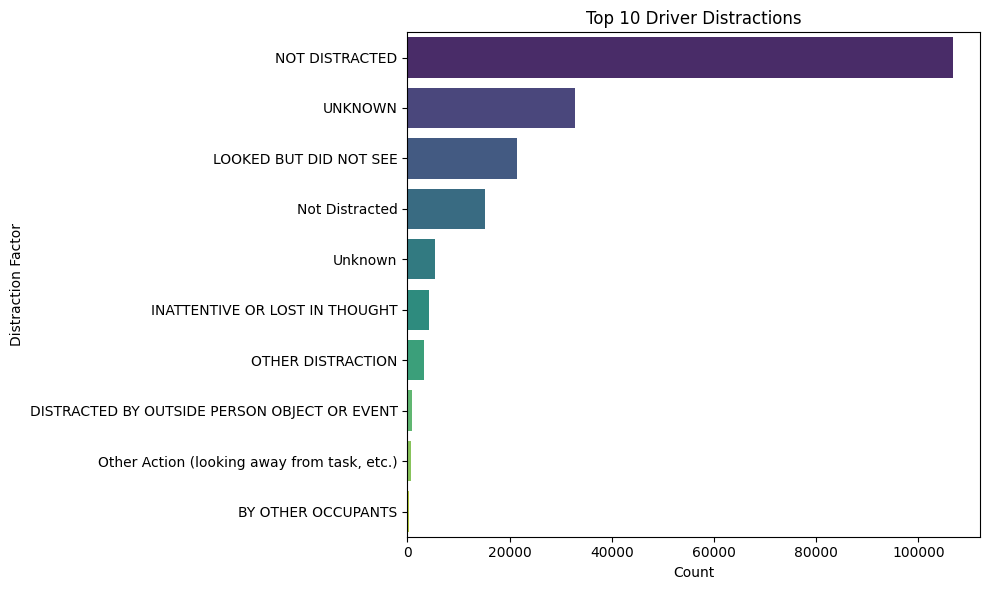

In [7]:
# Plot: Top 10 Driver Distractions
plt.figure(figsize=(10,6))
sns.countplot(
    data=df,
    y='Driver Distracted By',
    order=df['Driver Distracted By'].value_counts().head(10).index,
    palette='viridis'
)
plt.title('Top 10 Driver Distractions')
plt.xlabel('Count')
plt.ylabel('Distraction Factor')
plt.tight_layout()
plt.show()

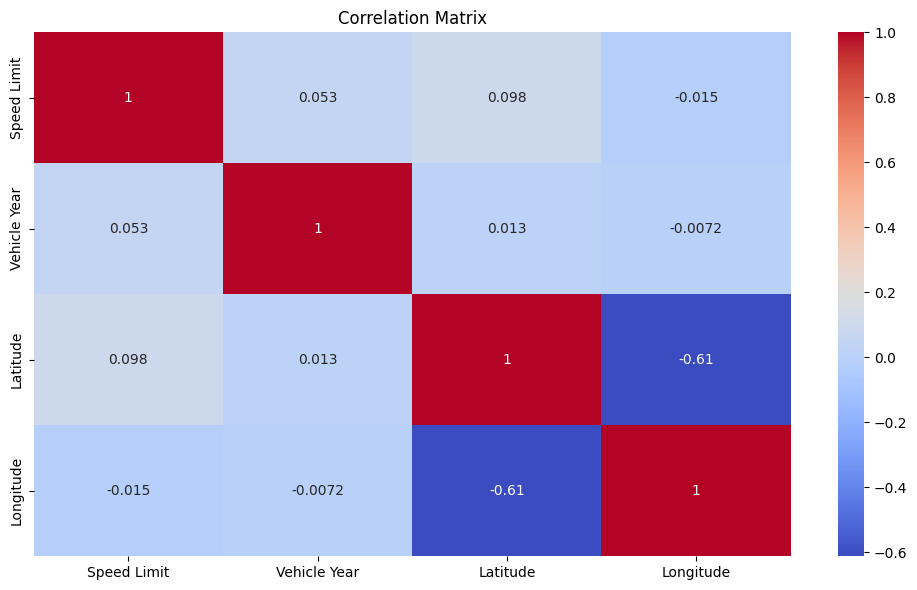

In [8]:
# Heatmap for correlation
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

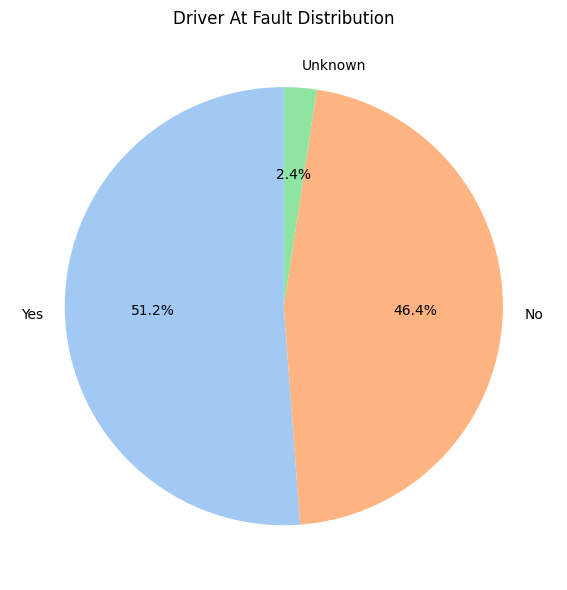

In [12]:
# Pie Chart: Driver At Fault Distribution
plt.figure(figsize=(6,6))
fault_counts = df['Driver At Fault'].value_counts()
plt.pie(fault_counts, labels=fault_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Driver At Fault Distribution')
plt.tight_layout()
plt.show()


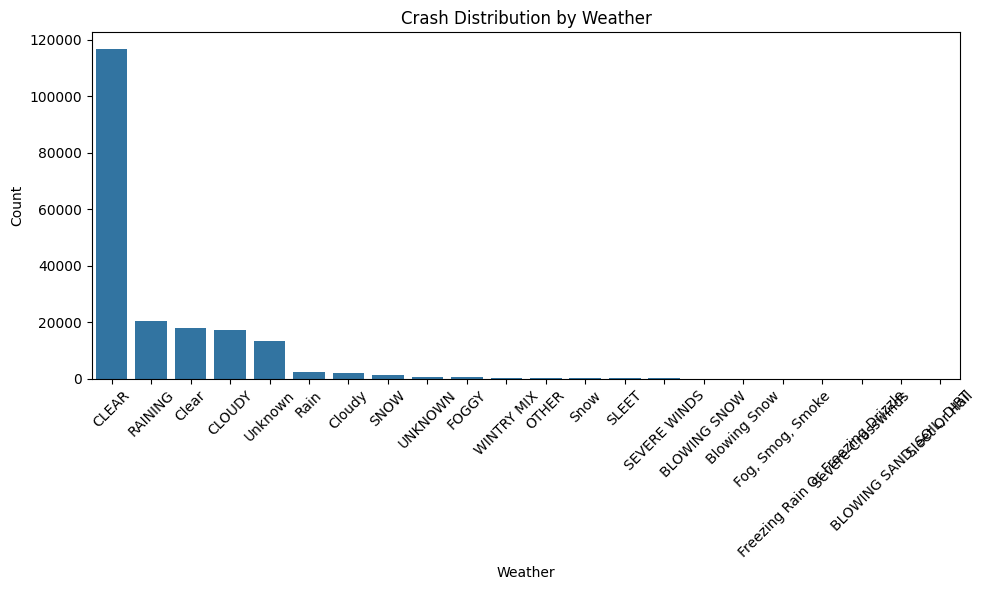

In [13]:
# Bar Plot: Weather Conditions
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Weather', order=df['Weather'].value_counts().index)
plt.title('Crash Distribution by Weather')
plt.xlabel('Weather')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [18]:
#🧪 Chi-Square Test to Analyze Association Between Driver Fault and Crash Location
from scipy.stats import chi2_contingency

# Create contingency table
contingency = pd.crosstab(df['Driver At Fault'], df['Location'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency)

print("\nChi-square test for 'Driver At Fault' vs 'Location':")
print(f"Chi2 Stat: {chi2:.3f}")
print(f"P-value: {p:.4f}")

if p < 0.05:
    print("✅ Significant association between driver fault and crash location.")
else:
    print("❌ No significant association between driver fault and crash location.")



Chi-square test for 'Driver At Fault' vs 'Location':
Chi2 Stat: 234527.629
P-value: 0.0000
✅ Significant association between driver fault and crash location.


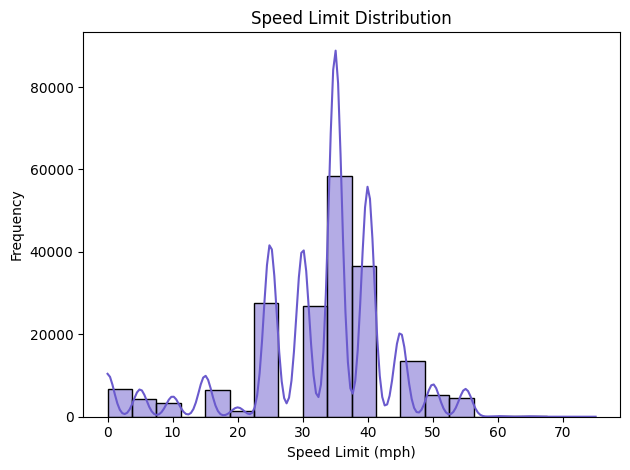

In [25]:
#histogram for displaying the speed limit of the car

sns.histplot(df['Speed Limit'].dropna(), bins=20, kde=True, color='slateblue')
plt.title('Speed Limit Distribution')
plt.xlabel('Speed Limit (mph)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

C:\Users\panka\AppData\Local\Temp\ipykernel_20572\1943168081.py:6: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:/Users/panka/Downloads/Crash_Reporting_-_Drivers_Data.csv")
C:\Users\panka\AppData\Local\Temp\ipykernel_20572\1943168081.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Driver At Fault', y='Speed Limit', palette="Set2")


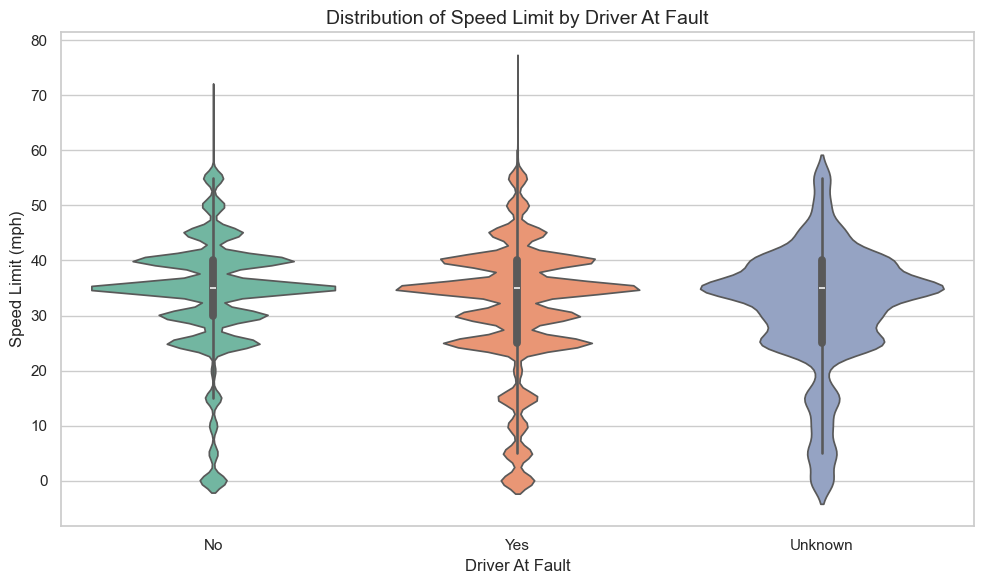

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("C:/Users/panka/Downloads/Crash_Reporting_-_Drivers_Data.csv")

# Set up the plot style
sns.set(style="whitegrid")

# Create the violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Driver At Fault', y='Speed Limit', palette="Set2")

# Add title and labels
plt.title("Distribution of Speed Limit by Driver At Fault", fontsize=14)
plt.xlabel("Driver At Fault")
plt.ylabel("Speed Limit (mph)")

plt.tight_layout()
plt.show()

